# Generalised elliptical model

In [1]:
import numpy as np
import dill

from matplotlib import pyplot as plt

# Use TeX
from matplotlib import rc
rc('font', size=18)
rc('text', usetex=True)
rc('font', family='serif')

from matplotlib.patches import Ellipse, Circle

from scipy.optimize import fsolve
from scipy.differentiate import derivative, jacobian

import time

# 1. Define the ellipse fields

We use here the following expressions of the ellipticity $e(\zeta)$, pointing angle $\phi(\zeta)$, and central position $\boldsymbol{x}_{\rm c}(\zeta)$ as a function of elliptical radius $\zeta$, inspired from the analysis of the isopotential contours of COLIBRE lenses:
$$
e(\zeta) = e_\infty + (e_0-e_\infty) \exp\left(-\frac{\zeta}{\Delta \zeta_e}\right)
$$
$$
\phi(\zeta) = \phi_0 + \frac{4\Delta\phi}{\pi} \arctan\left(\frac{\zeta - \zeta_0}{\Delta \zeta_\phi}\right)
$$
$$
x_{\rm c}(\zeta) = d_x \zeta \qquad
y_{\rm c}(\zeta) = d_y \zeta
$$

In [2]:
def ellipse_fields(zeta, e_inf, e_0, Dzeta_e, phi_0, Dphi, zeta_0, Dzeta_phi, drift_x, drift_y):
    """
    Calculates the ellipticity, pointing angle and central position of the ellipse
    with elliptical radius zeta, as well as their derivatives with respect to zeta.
    """

    e    = e_inf + (e_0 - e_inf) * np.exp(-zeta / Dzeta_e)
    e_z  = - (e_0 - e_inf) / Dzeta_e * np.exp(-zeta / Dzeta_e)
    e_zz = - e_z / Dzeta_e
    
    phi    = phi_0 + 4 * Dphi / np.pi * np.arctan((zeta - zeta_0) / Dzeta_phi)
    phi_z  = 4 * Dphi / np.pi / Dzeta_phi / (1 + (zeta - zeta_0)**2 / Dzeta_phi**2)
    phi_zz = - np.pi * (zeta - zeta_0) * phi_z**2 / 2 / Dphi / Dzeta_phi
    
    
    xc    = drift_x * zeta
    xc_z  = drift_x
    xc_zz = 0
    
    yc    = drift_y * zeta
    yc_z  = drift_y
    yc_zz = 0

    return (e, phi, xc, yc), (e_z, phi_z, xc_z, yc_z), (e_zz, phi_zz, xc_zz, yc_zz)

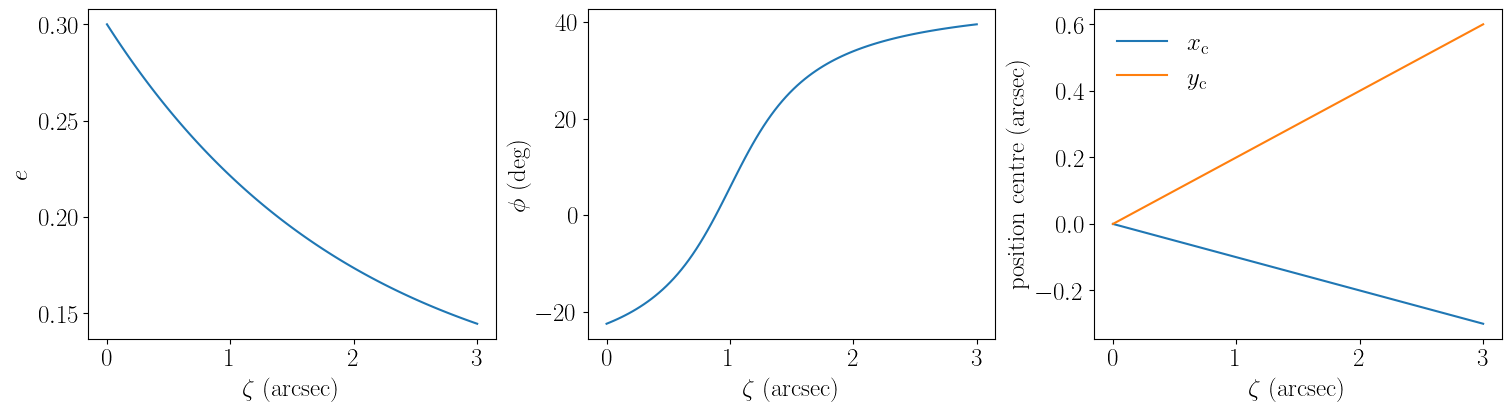

In [3]:
params_ellipticity = {'e_inf': 0.1 , 'e_0': 0.3, 'Dzeta_e': 2}
params_pointing_angle = {'phi_0': 0.1, 'Dphi': 20 * np.pi / 180, 'zeta_0': 1, 'Dzeta_phi': 0.5}
params_centre = {'drift_x': -0.1, 'drift_y': 0.2}
params_ellipses = params_ellipticity | params_pointing_angle | params_centre

zeta = np.linspace(0, 3, 100) # elliptical radius in arcsec
(e, phi, xc, yc), _, _ = ellipse_fields(zeta, **params_ellipses)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')

ax=axes[0]
ax.plot(zeta, e)
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r'$e$')

ax=axes[1]
ax.plot(zeta, phi * 180 / np.pi)
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r'$\phi$ (deg)')

ax=axes[2]
ax.plot(zeta, xc, label=r'$x_{\rm c}$')
ax.plot(zeta, yc, label=r'$y_{\rm c}$')
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r'position centre (arcsec)')
ax.legend(frameon=False)

plt.show();

# 2. Determine the elliptical radius

The elliptical radius $\zeta(\boldsymbol{x})$ is the solution of $\zeta = F(\zeta; \boldsymbol{x})$, with
$$
F^2(\zeta;\boldsymbol{x})
= [\boldsymbol{X} - \boldsymbol{X}_{\rm c}(\zeta)]^T \boldsymbol{E}(\zeta) [\boldsymbol{X} - \boldsymbol{X}_{\rm c}(\zeta)]
$$
and
$$
\boldsymbol{E}
= \sqrt{1+e^2}\,\boldsymbol{1}_2
-
\begin{bmatrix}
e_1 & e_2 \\
e_2 & -e_1
\end{bmatrix}
=
\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}
\begin{bmatrix}
q & 0 \\
0 & 1/q
\end{bmatrix}
\begin{bmatrix}
\cos\phi & \sin\phi \\
-\sin\phi & \cos\phi
\end{bmatrix}
$$
if $(e_1, e_2)=e(\cos 2\phi, \sin2\phi)$.

I use an iterative perturbative method using a quadratic expansion of the function $F$ above to solve it numerically in an efficient way. The use of a quadratic method is motivated by the fact that we must compute the second derivatives of the various fields to get the Hessian matrix anyway.

The method consists in starting from an approximation $\zeta_0=\sqrt{x^2+y^2}$ of the solution, and then
$$
\zeta = \zeta_0 + \zeta_1 + \zeta_2 = F(\zeta_0) + (\zeta_1+\zeta_2) F'(\zeta_0) + \frac{1}{2} \, \zeta_1^2 F''(\zeta_1) \ ,
$$
where a prime denotes a partial derivative with respect to $\zeta$, i.e. $F'(\boldsymbol{x})\equiv \partial F/\partial\zeta$. We find
$$
\zeta_1 = \frac{F(\zeta_0)-\zeta_0}{1 - F'(\zeta_0)}
\qquad
\zeta_2 = \frac{F''(\zeta_0)}{1-F'(\zeta_0)} \, \zeta_1^2 \ .
$$

## Properties of function $F$

The key is to compute $F$ and its derivatives. Denoting $\boldsymbol{X}_1=\boldsymbol{X}-\boldsymbol{X}_{\rm c}$, we have
$$
F'
= F^{-1}
\left[
\frac{1}{2} \boldsymbol{X}_1^T \boldsymbol{E}' \boldsymbol{X}_1 - (\boldsymbol{X}_{\rm c}')^T \boldsymbol{E}\boldsymbol{X}_1
\right]
$$
with the first derivative
$$
\boldsymbol{E}' = e' \partial_e \boldsymbol{E} + \phi' \partial_\phi \boldsymbol{E}
\qquad
\partial_e \boldsymbol{E} 
=
\frac{e}{\sqrt{1+e^2}} \, \boldsymbol{1}_2
-
\begin{bmatrix}
\cos 2\phi & \sin 2\phi \\
\sin 2\phi & -\cos 2\phi
\end{bmatrix}
\qquad
\partial_\phi \boldsymbol{E} 
=
2
\begin{bmatrix}
e_2 & -e_1 \\
-e_1 & -e_2
\end{bmatrix}
$$
and the second derivative
$$
F''
= F^{-1}
\left[
- (\boldsymbol{X}_{\rm c}'')^T \boldsymbol{E}\boldsymbol{X}_1
- 2(\boldsymbol{X}_{\rm c}')^T \boldsymbol{E}'\boldsymbol{X}_1
+ (\boldsymbol{X}_{\rm c}')^T \boldsymbol{E}\boldsymbol{X}'_{\rm c}
+ \frac{1}{2} \boldsymbol{X}_1^T \boldsymbol{E}'' \boldsymbol{X}_1
- (F')^2
\right]
$$
with
$$
\boldsymbol{E}''
= e'' \partial_e\boldsymbol{E} + (e')^2 \partial^2_e\boldsymbol{E} + 2e'\phi' \partial_e\partial_\phi\boldsymbol{E}
+ \phi'' \partial_\phi\boldsymbol{E} + (\phi')^2\partial^2_\phi\boldsymbol{E}
$$
and
$$
\partial_e^2\boldsymbol{E} = [(1+e^2)^{-1/2} - e(1+e^2)^{-3/2}]\boldsymbol{1}_2
\qquad
\partial_e\partial\phi\boldsymbol{E}
= 2
\begin{bmatrix}
\sin 2\phi & -\cos 2\phi \\
-\cos 2\phi & -\sin 2\phi
\end{bmatrix}
\qquad
\partial_\phi^2\boldsymbol{E} =
4
\begin{bmatrix}
e_1 & e_2 \\
e_2 & -e_1
\end{bmatrix}
$$

In [4]:
def elliptical_radius_function(x, y, zeta, second_derivatives=True, **params):
    """
    Define F such that zeta = F(zeta; x, y)
    Returns F and its first and second derivatives with respect to zeta, x and y
    """

    # properties of the ellipse at zeta
    
    (e, phi, xc, yc), (e_z, phi_z, xc_z, yc_z), (e_zz, phi_zz, xc_zz, yc_zz) = ellipse_fields(zeta, **params)

    
    # F
    
    x1 = x - xc
    y1 = y - yc

    c2 = np.cos(2*phi)
    s2 = np.sin(2*phi)

    e1 = e * c2
    e2 = e * s2
    
    E_xx = (1 + e**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e**2)**0.5 + e1

    EX1_x = E_xx * x1 + E_xy * y1
    EX1_y = E_yx * x1 + E_yy * y1
        
    F2 = EX1_x * x1 + EX1_y * y1
    F = F2**0.5

    
    # dF / d zeta

    # E'
    E_xx_e = e / (1 + e**2)**0.5 - np.cos(2*phi)
    E_xy_e = - np.sin(2*phi)
    E_yx_e = E_xy_e
    E_yy_e = e / (1 + e**2)**0.5 + np.cos(2*phi)

    E_xx_phi = 2 * e2
    E_xy_phi = - 2 * e1
    E_yx_phi = E_xy_phi
    E_yy_phi = - 2 * e2

    E_xx_z = e_z * E_xx_e + phi_z * E_xx_phi
    E_xy_z = e_z * E_xy_e + phi_z * E_xy_phi
    E_yx_z = E_xy_z
    E_yy_z = e_z * E_yy_e + phi_z * E_yy_phi

    # E' X1
    E_zX1_x = (E_xx_z * x1 + E_xy_z * y1)
    E_zX1_y = (E_yx_z * x1 + E_yy_z * y1)

    # E Xc'
    EXc_z_x = E_xx * xc_z + E_xy * yc_z
    EXc_z_y = E_yx * xc_z + E_yy * yc_z

    # Xc' E X1
    Xc_zEX1 = xc_z * EX1_x + yc_z * EX1_y

    # X1 E' X1
    X1E_zX1 = x1 * E_zX1_x + y1 * E_zX1_y
    
    F_z = (X1E_zX1 / 2 - Xc_zEX1) / F


    # Spatial gradients

    F_x = EX1_x / F
    F_y = EX1_y / F

    
    if second_derivatives:
        
        # d^2F / d zeta^2
    
        # E''
        E_xx_ee = (1 + e**2)**(-0.5) - e * (1 + e**2)**(-1.5)
        E_xy_ee = 0
        E_yx_ee = 0
        E_yy_ee = E_xx_ee
    
        E_xx_ephi = 2 * s2
        E_xy_ephi = - 2 * c2
        E_yx_ephi = E_xy_ephi
        E_yy_ephi = - 2 * s2
    
        E_xx_phiphi = 4 * e1
        E_xy_phiphi = 4 * e2
        E_yx_phiphi = E_xy_phiphi
        E_yy_phiphi = - 4 * e1
        
        E_xx_zz = e_zz * E_xx_e + e_z**2 * E_xx_ee + 2 * e_z * phi_z * E_xx_ephi + phi_zz * E_xx_phi + phi_z**2 * E_xx_phiphi
        E_xy_zz = e_zz * E_xy_e + e_z**2 * E_xy_ee + 2 * e_z * phi_z * E_xy_ephi + phi_zz * E_xy_phi + phi_z**2 * E_xy_phiphi
        E_yx_zz = E_xy_zz
        E_yy_zz = e_zz * E_yy_e + e_z**2 * E_yy_ee + 2 * e_z * phi_z * E_yy_ephi + phi_zz * E_yy_phi + phi_z**2 * E_yy_phiphi
    
        # E'' X1
        E_zzX1_x = E_xx_zz * x1 + E_xy_zz * y1
        E_zzX1_y = E_yx_zz * x1 + E_yy_zz * y1
        
        Xc_zzEX1  = xc_zz * EX1_x  + yc_zz * EX1_y
        Xc_zE_zX1 = xc_z * E_zX1_x + yc_z * E_zX1_y
        Xc_zEXc_z = xc_z * EXc_z_x + yc_z * EXc_z_y
        X1E_zzX1  = x1 * E_zzX1_x  + y1 * E_zzX1_y
        
        F_zz = (-Xc_zzEX1 - 2 * Xc_zE_zX1 + Xc_zEXc_z + 0.5 * X1E_zzX1 - F_z**2) / F

    
        # rest of the Hessian
    
        F_xx = (E_xx - F_x * F_x) / F
        F_xy = (E_xy - F_x * F_y) / F
        F_yy = (E_yy - F_y * F_y) / F
        
        F_xz = (E_zX1_x -  EXc_z_x - F_x * F_z) / F
        F_yz = (E_zX1_y -  EXc_z_y - F_y * F_z) / F

    else:
        F_xx = F_xy = F_xz = F_yy = F_yz = F_zz = 0

    
    return F, (F_x, F_y, F_z), (F_xx, F_xy, F_xz, F_yy, F_yz, F_zz)

Check that the derivatives are consistent

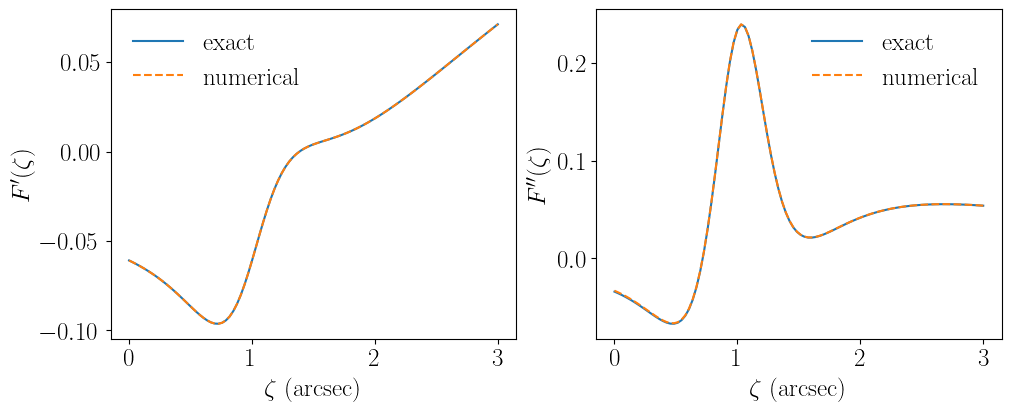

In [5]:
zeta = np.linspace(0, 3, 100)
x = 2 * np.random.rand() - 1
y = 2 * np.random.rand() - 1
F, (_, _, F_z), (_, _, _, _, _, F_zz) = elliptical_radius_function(x, y, zeta, **params_ellipses)

# compute F_z numerically
func = lambda zeta: elliptical_radius_function(x, y, zeta, **params_ellipses)[0]
res = derivative(func, zeta)
F_z_num = res.df

# compute F_zz numerically
func = lambda zeta: elliptical_radius_function(x, y, zeta, **params_ellipses)[1][2]
res = derivative(func, zeta)
F_zz_num = res.df

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')

ax=axes[0]
ax.plot(zeta, F_z, label='exact')
ax.plot(zeta, F_z_num, '--', label='numerical')
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r"$F'(\zeta)$")
ax.legend(frameon=False)

ax=axes[1]
ax.plot(zeta, F_zz, label='exact')
ax.plot(zeta, F_zz_num, '--', label='numerical')
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r"$F''(\zeta)$")
ax.legend(frameon=False)

plt.show();

## Solving for $\zeta$

In [6]:
def get_elliptical_radius(x, y, N_iter=3, second_derivatives=True, **params):
    """
    Iteratively solve zeta = F(x, zeta) for zeta.
    """
    
    zeta = (x**2 + y**2)**0.5 # first guess
    
    # get zeta iteratively
    for i in range(N_iter):

        F, (F_x, F_y, F_z), (F_xx, F_xy, F_xz, F_yy, F_yz, F_zz) = elliptical_radius_function(x, y, zeta, second_derivatives, **params)
        
        zeta1 = (F - zeta) / (1 - F_z)
        zeta2 = F_zz / 2 / (1 - F_z) * zeta1**2
        zeta += zeta1 + zeta2

    
    # gradient of zeta
    zeta_x = F_x / (1 - F_z)
    zeta_y = F_y / (1 - F_z)

    
    # Hessian of zeta
    if second_derivatives:
        zeta_xx = (F_xx + F_xz * zeta_x + F_xz * zeta_x + F_zz * zeta_x * zeta_x) / (1 - F_z)
        zeta_xy = (F_xy + F_xz * zeta_y + F_yz * zeta_x + F_zz * zeta_x * zeta_y) / (1 - F_z)
        zeta_yy = (F_yy + F_yz * zeta_y + F_yz * zeta_y + F_zz * zeta_y * zeta_y) / (1 - F_z)
    else:
        zeta_xx = zeta_xy = zeta_yy = 0

    
    return zeta, (zeta_x, zeta_y), (zeta_xx, zeta_xy, zeta_yy)

Check that it works

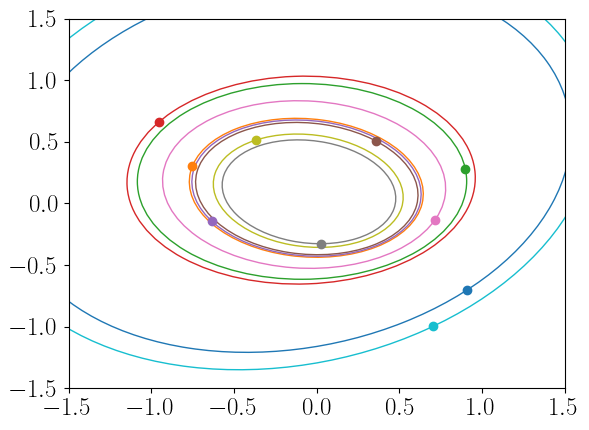

In [7]:
# generate a set of N random points in [-1, 1]^2
N = 10
x = 2 * np.random.random_sample(N) - 1
y = 2 * np.random.random_sample(N) - 1

# get the corresponding elliptical radii
zetas = get_elliptical_radius(x, y, N_iter=3, **params_ellipses)[0]

# plot the points and the ellipses
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots()

for i, zeta in enumerate(zetas):

    (e, phi, x0, y0), _, _ = ellipse_fields(zeta, **params_ellipses)
    q = (1 + e**2)**0.5 - e
    a = zeta / q**0.5
    b = zeta * q**0.5

    colour = colours[i% len(colours)]
    
    ellipse = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor=colour
    )
    
    ax.plot(x[i], y[i], 'o', color=colour)
    ax.add_artist(ellipse)

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.show()

Convergence as a function of the number of iterations

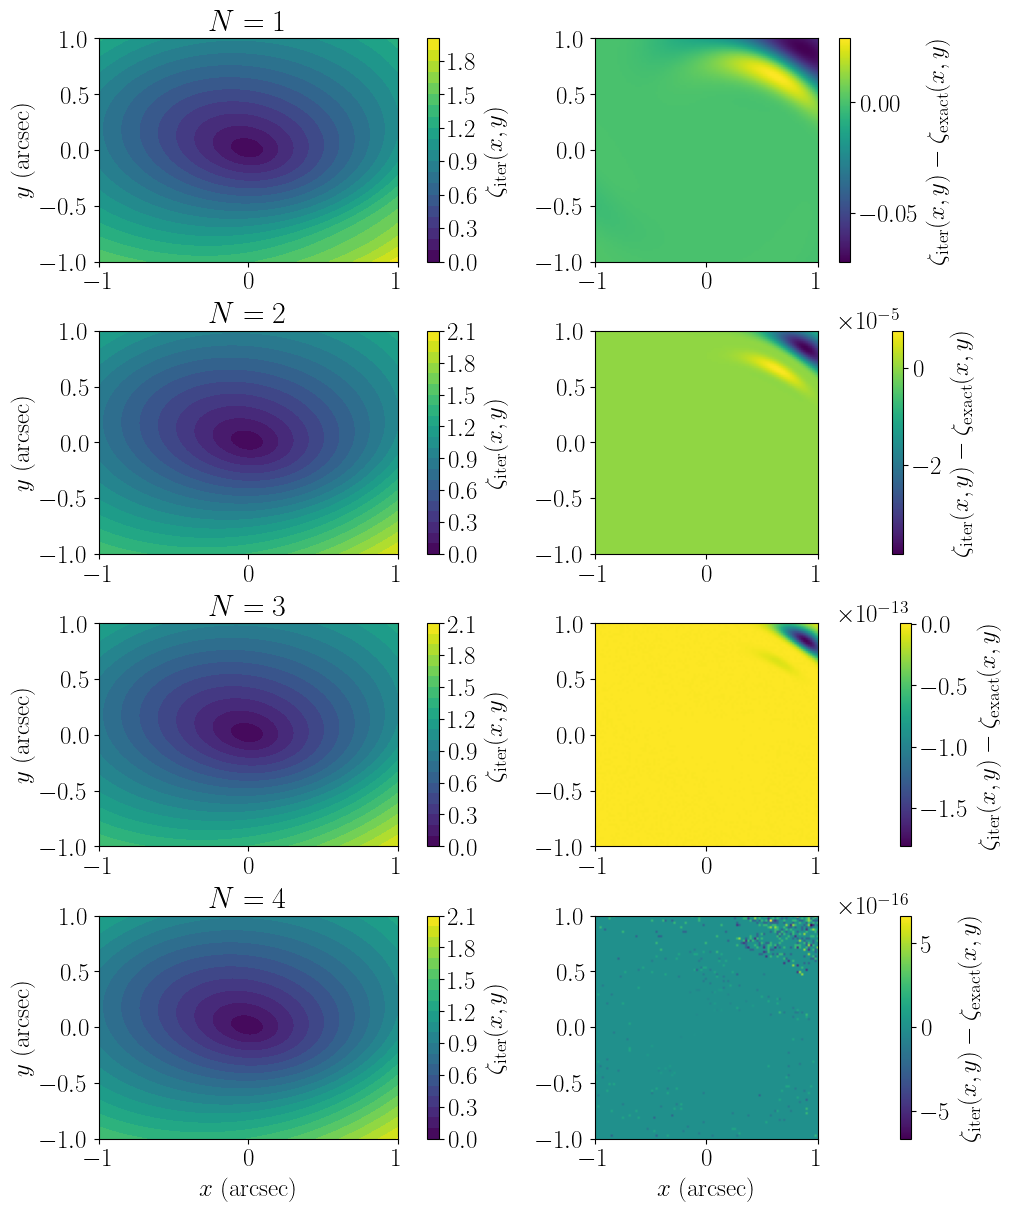

In [8]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

N_iters = [1, 2, 3, 4]
zeta_exact = get_elliptical_radius(X, Y, 10, **params_ellipses)[0]

fig, axes = plt.subplots(len(N_iters), 2, figsize=(10, 3*len(N_iters)), layout="constrained")

for i, N_iter in enumerate(N_iters):

    zeta = get_elliptical_radius(X, Y, N_iter, **params_ellipses)[0]
    diff = zeta - zeta_exact

    #ax = axes[i, 0]
    #contours = ax.contourf(X, Y, zeta_exact, levels=20)
    #fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm exact}(x, y)$')

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm iter}(x, y)$')
    ax.set_title(r"$N = {}$".format(N_iter))

    ax = axes[i, 1]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=r'$\zeta_{\rm iter}(x, y) - \zeta_{\rm exact}(x, y)$')

for i in range(len(N_iters)):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(2):
    axes[len(N_iters)-1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

In [9]:
print("Timing with second derivatives:")

for N_iter in N_iters:

    start = time.perf_counter()
    get_elliptical_radius(X, Y, N_iter, **params_ellipses)
    end = time.perf_counter()
    timing = 1000 * (end - start) # ms

    print("Time for {} iteration(s) = {} ms".format(N_iter, timing))

print("""
Timing without second derivatives:""")

for N_iter in N_iters:

    start = time.perf_counter()
    get_elliptical_radius(X, Y, N_iter, second_derivatives=False, **params_ellipses)
    end = time.perf_counter()
    timing = 1000 * (end - start) # ms

    print("Time for {} iteration(s) = {} ms".format(N_iter, timing))

Timing with second derivatives:
Time for 1 iteration(s) = 3.5412409342825413 ms
Time for 2 iteration(s) = 6.8878778256475925 ms
Time for 3 iteration(s) = 8.72801709920168 ms
Time for 4 iteration(s) = 10.497084818780422 ms

Timing without second derivatives:
Time for 1 iteration(s) = 1.5154778957366943 ms
Time for 2 iteration(s) = 3.0272877775132656 ms
Time for 3 iteration(s) = 4.394324030727148 ms
Time for 4 iteration(s) = 5.597488954663277 ms


## Gradient of $\zeta$

In [10]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

# calculation from iterative method
_, (zeta_x, zeta_y), _ = get_elliptical_radius(X, Y, N_iter=3, **params_ellipses)


# calculation from numerical differentiation

zeta_exact = lambda x, y: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[0]
res = derivative(zeta_exact, X, args=(Y,))
zeta_x_num = res.df

zeta_exact = lambda y, x: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[0]
res = derivative(zeta_exact, Y, args=(X,))
zeta_y_num = res.df

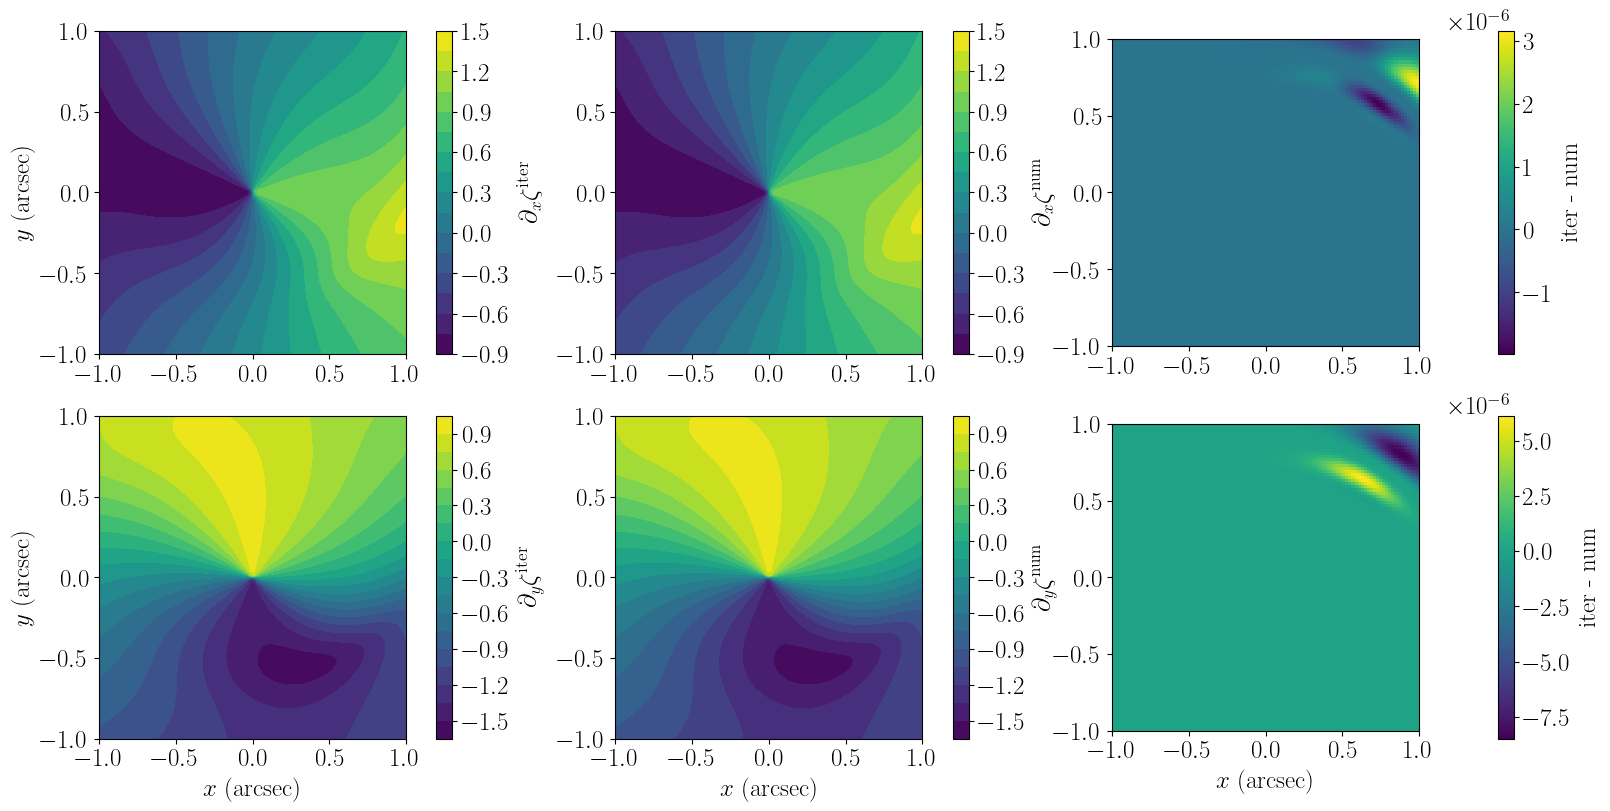

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 4*2), layout="constrained")

grad_zeta_num = [zeta_x_num, zeta_y_num]
labels = [[r'$\partial_x\zeta^{\rm iter}$', r'$\partial_x\zeta^{\rm num}$', r'iter - num'],
          [r'$\partial_y\zeta^{\rm iter}$', r'$\partial_y\zeta^{\rm num}$', r'iter - num']]

for i, zeta_i in enumerate([zeta_x, zeta_y]):

    zeta_i_num = grad_zeta_num[i]
    diff = zeta_i - zeta_i_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_i, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta_i_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(2):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

## Hessian of $\zeta$

In [12]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

# calculation from iterative method
_, _, (zeta_xx, zeta_xy, zeta_yy) = get_elliptical_radius(X, Y, N_iter=3, **params_ellipses)

zeta_x = lambda x, y: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[1][0]
res = derivative(zeta_x, X, args=(Y,))
zeta_xx_num = res.df

zeta_x = lambda y, x: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[1][0]
res = derivative(zeta_x, Y, args=(X,))
zeta_xy_num = res.df

zeta_y = lambda y, x: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[1][1]
res = derivative(zeta_y, Y, args=(X,))
zeta_yy_num = res.df

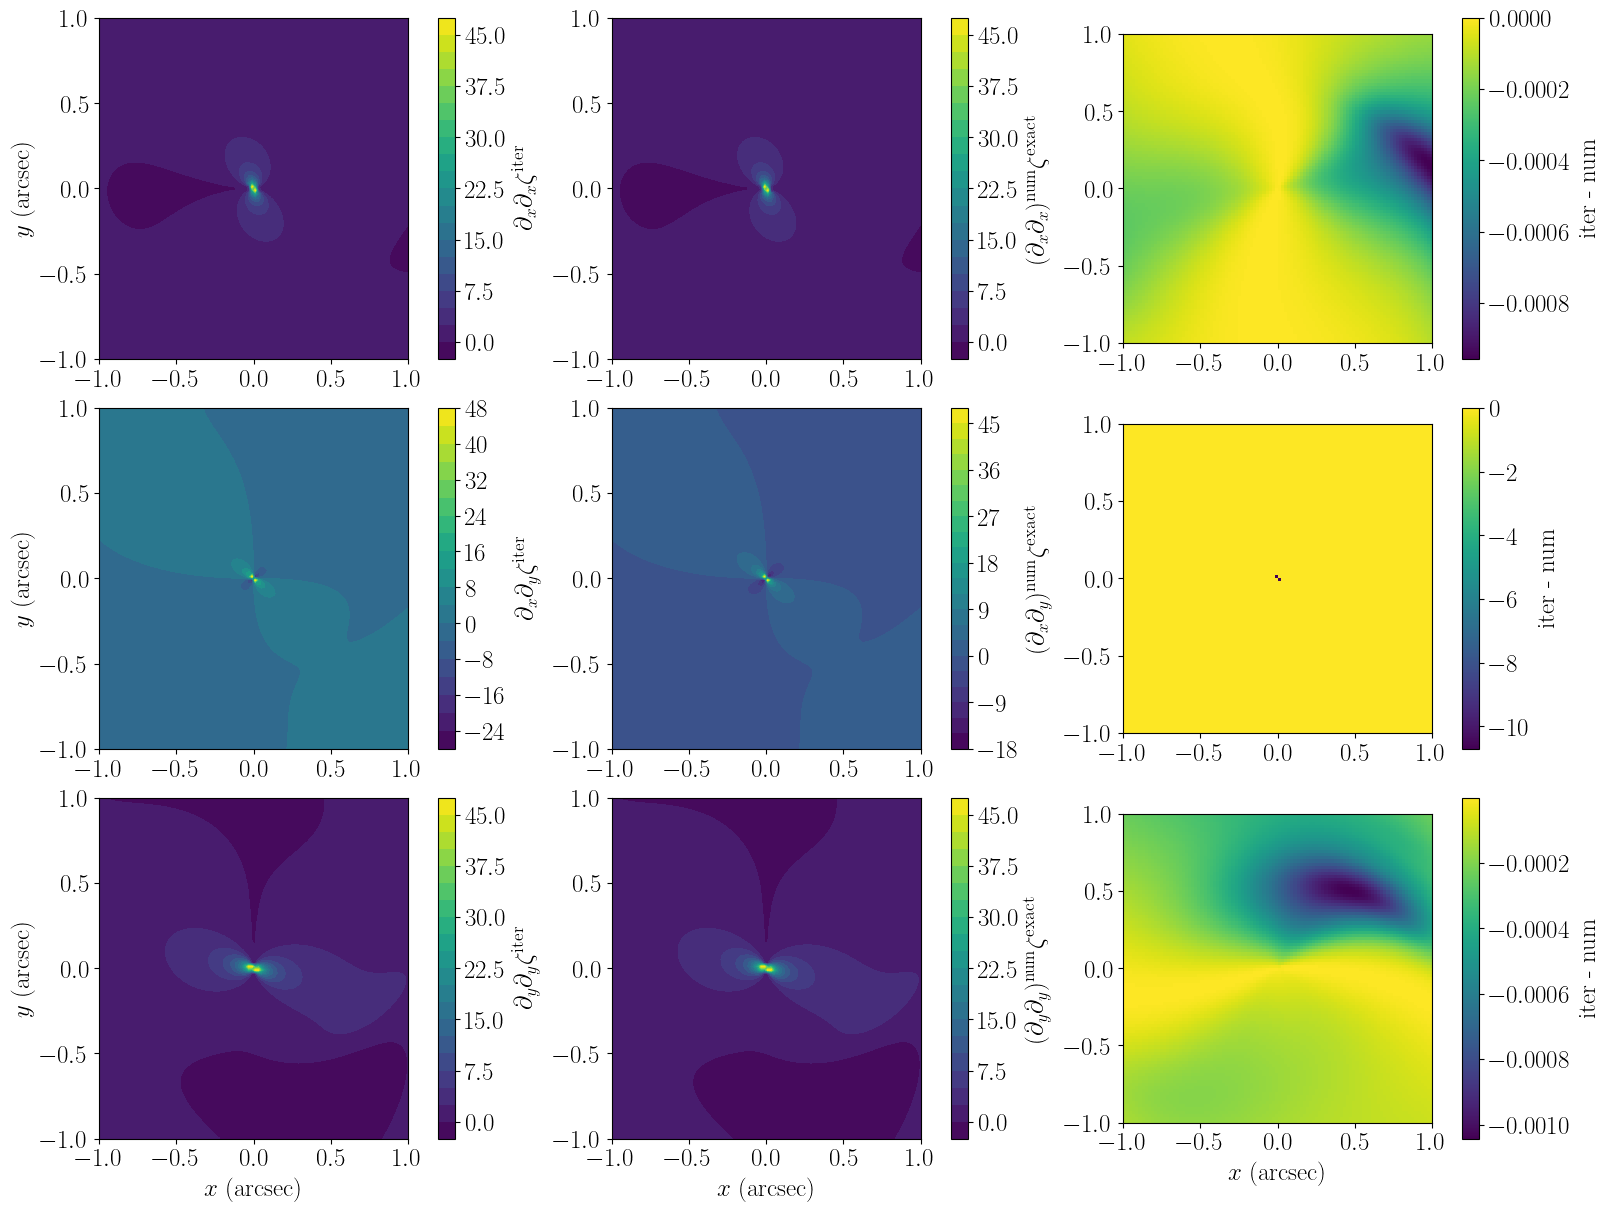

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 4*3), layout="constrained")

hessian_num = [zeta_xx_num, zeta_xy_num, zeta_yy_num]
labels = [[r'$\partial_x\partial_x\zeta^{\rm iter}$', r'$(\partial_x\partial_x)^{\rm num}\zeta^{\rm exact}$', r'iter - num'],
          [r'$\partial_x\partial_y\zeta^{\rm iter}$', r'$(\partial_x\partial_y)^{\rm num}\zeta^{\rm exact}$', r'iter - num'],
          [r'$\partial_y\partial_y\zeta^{\rm iter}$', r'$(\partial_y\partial_y)^{\rm num}\zeta^{\rm exact}$', r'iter - num']]

for i, zeta_ij in enumerate([zeta_xx, zeta_xy, zeta_yy]):

    zeta_ij_num = hessian_num[i]
    diff = zeta_ij - zeta_ij_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_ij, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta_ij_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(3):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[2, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

# 3. Radial profile of the potential

We parameterise the potential as
$$
\psi(\theta) = \psi_0\left[1 + \left(\frac{\theta}{\theta_{\rm c}}\right)^s\right]^{\frac{3-\gamma}{s}}
$$
with
$$
\psi_0
\equiv
\frac{\theta_{\rm E}^2}{3-\gamma}
\left(\frac{\theta_{\rm c}}{\theta_{\rm E}}\right)^s
\left[1 + \left(\frac{\theta_{\rm E}}{\theta_{\rm c}}\right)^{s}\right]^{1-\frac{3-\gamma}{s}}
$$
ensuring that the Einstein radius is $\theta_{\rm E}$.

In [14]:
def potential_radial(theta, theta_E, theta_core, sharpness, outer_slope):
    """
    Axially symmetric cored power law potential.
    """
    
    power = (3 - outer_slope) / sharpness
    
    # normalisation to ensure that the Einstein radius is theta_E
    R = theta_core / theta_E
    psi0 = theta_E**2 / (3 - outer_slope) * R**sharpness * (1 + R**(-sharpness))**(1 - power)

    
    psi    = psi0 * (1 + (theta/theta_core)**sharpness)**power
    
    psi_t  = theta_E * (theta/theta_E)**(sharpness-1) * (
        (theta_core**sharpness + theta**sharpness)/(theta_core**sharpness + theta_E**sharpness))**(power - 1)
    
    psi_tt = (sharpness - 1 + (3 - outer_slope - sharpness)
              * theta**sharpness / (theta_core**sharpness + theta**sharpness)) * psi_t / theta

    
    return psi, psi_t, psi_tt

Check consistency of the derivatives

/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_14296/2415491580.py:13: RuntimeWarning: invalid value encountered in power
  psi    = psi0 * (1 + (theta/theta_core)**sharpness)**power
/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_14296/2415491580.py:15: RuntimeWarning: invalid value encountered in power
  psi_t  = theta_E * (theta/theta_E)**(sharpness-1) * (
/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_14296/2415491580.py:16: RuntimeWarning: invalid value encountered in power
  (theta_core**sharpness + theta**sharpness)/(theta_core**sharpness + theta_E**sharpness))**(power - 1)
/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_14296/2415491580.py:19: RuntimeWarning: invalid value encountered in power
  * theta**sharpness / (theta_core**sharpness + theta**sharpness)) * psi_t / theta


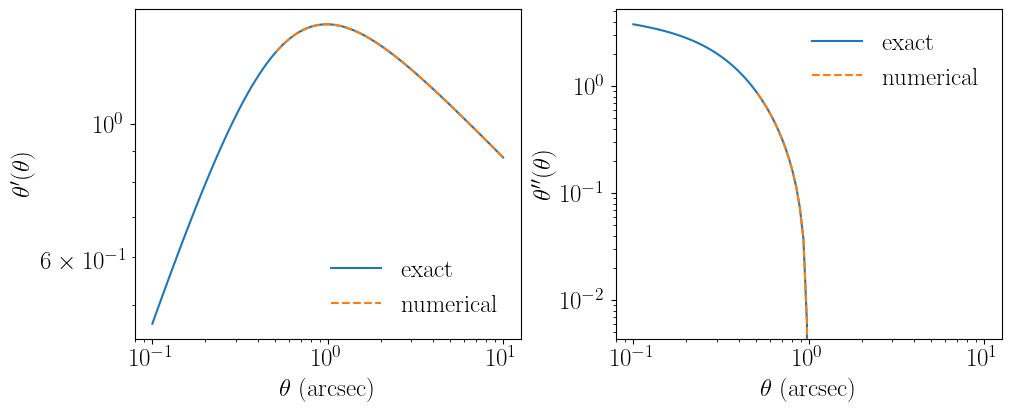

In [15]:
params_radial = {'theta_E': 1.43, 'theta_core': 0.56, 'sharpness': 1.86, 'outer_slope': 2.3}

zeta = np.logspace(-1, 1, 100)
psi, psi_z, psi_zz = potential_radial(zeta, **params_radial)

# compute psi_z numerically
func = lambda zeta: potential_radial(zeta, **params_radial)[0]
res = derivative(func, zeta)
psi_z_num = res.df

# compute psi_zz numerically
func = lambda zeta: potential_radial(zeta, **params_radial)[1]
res = derivative(func, zeta)
psi_zz_num = res.df

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')

ax=axes[0]
ax.loglog(zeta, psi_z, label='exact')
ax.loglog(zeta, psi_z_num, '--', label='numerical')
ax.set_xlabel(r'$\theta$ (arcsec)')
ax.set_ylabel(r"$\theta'(\theta)$")
ax.legend(frameon=False)

ax=axes[1]
ax.loglog(zeta, psi_zz, label='exact')
ax.loglog(zeta, psi_zz_num, '--', label='numerical')
ax.set_xlabel(r'$\theta$ (arcsec)')
ax.set_ylabel(r"$\theta''(\theta)$")
ax.legend(frameon=False)

plt.show();

Check normalisation
$$
\bar{\kappa}(<\theta) = \frac{1}{\theta} \frac{{\rm d}\psi}{{\rm d}\theta}
$$
and we must have $\bar{\kappa}(<\theta_{\rm E})=1$

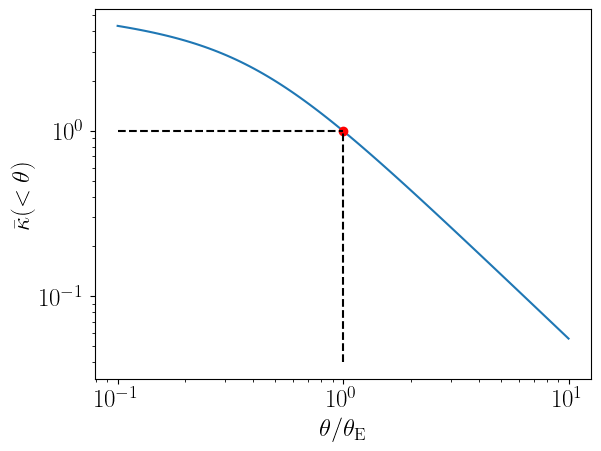

In [16]:
params_radial = {'theta_E': 1.43, 'theta_core': 0.56, 'sharpness': 1.86, 'outer_slope': 2.3}

theta = np.logspace(-1,  1, 100) * params_radial['theta_E']
psi, psi_z, psi_zz = potential_radial(theta, **params_radial)

plt.loglog(theta/params_radial['theta_E'], psi_z/theta)
plt.loglog([1], [1], 'ro')
plt.loglog([1e-1, 1], [1, 1], 'k--')
plt.loglog([1, 1], [4e-2, 1], 'k--')
plt.xlabel(r'$\theta/\theta_{\rm E}$')
plt.ylabel(r'$\bar{\kappa}(<\theta)$')
plt.show()

# 4. Combining radial profile and elliptical fields

In [17]:
params_ellipticity = {'e_inf': 0.1 , 'e_0': 0.4, 'Dzeta_e': 1}
params_pointing_angle = {'phi_0': 0.87, 'Dphi': 0.3, 'zeta_0': 0, 'Dzeta_phi': 1}
params_centre = {'drift_x': -0.12, 'drift_y': -0.03}
params_ellipses = params_ellipticity | params_pointing_angle | params_centre

params_radial = {'theta_E': 1.43, 'theta_core': 0.56, 'sharpness': 1.54, 'outer_slope': 2.3}

In [18]:
def lensing_fields(x, y, N_iter=3, second_derivatives=True):

    zeta, (zeta_x, zeta_y), (zeta_xx, zeta_xy, zeta_yy) = get_elliptical_radius(x, y, N_iter, second_derivatives, **params_ellipses)
    psi, psi_t, psi_tt = potential_radial(zeta, **params_radial)

    # displacement
    alpha_x = psi_t * zeta_x
    alpha_y = psi_t * zeta_y

    # Hessian
    if second_derivatives:
        H_xx = psi_tt * zeta_x * zeta_x + psi_t * zeta_xx
        H_xy = psi_tt * zeta_x * zeta_y + psi_t * zeta_xy
        H_yy = psi_tt * zeta_y * zeta_y + psi_t * zeta_yy
    else:
        H_xx = H_xy = H_yy = 0

    return psi, (alpha_x, alpha_y), (H_xx, H_xy, H_yy)

Plot the various fields

In [19]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

start = time.perf_counter()
psi, (alpha_x, alpha_y), (H_xx, H_xy, H_yy) = lensing_fields(X * params_radial['theta_E'], Y * params_radial['theta_E'])
end = time.perf_counter()
timing = 1000 * (end - start) # ms
print("Time for the whole grid = {} ms".format(timing))

Time for the whole grid = 14.244878198951483 ms


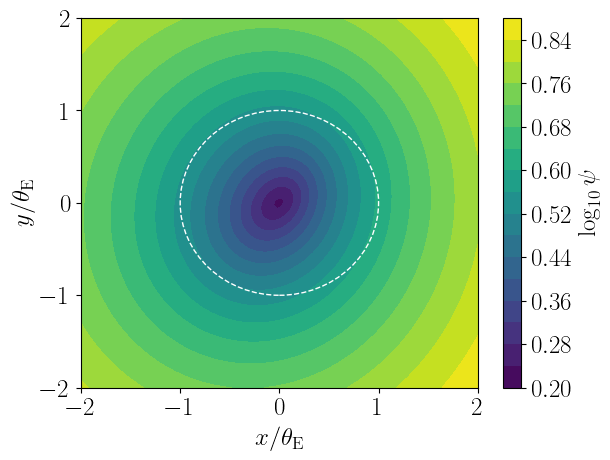

In [20]:
fig, ax = plt.subplots()

contours = ax.contourf(X, Y, np.log10(psi), levels=20)
fig.colorbar(contours, ax=ax, label=r'$\log_{10}\psi$')

# Einstein radius for indication
ax.add_artist(Circle(xy=(0, 0), radius=1, facecolor="none", edgecolor='white', ls='--'))

# Core ellipse
#x0 = drift_x * theta_core
#y0 = drift_y * theta_core
#q = (1 + e**2)**0.5 - e
#a = theta_core / q**0.5
#b = theta_core * q**0.5
#ellipse_core = Ellipse(
#    xy=(x0, y0),
#    width=2*a,
#    height=2*b,
#   angle=phi * 180 / np.pi,
#    facecolor="none",
#    edgecolor='orange'
#    )
#ax.add_artist(ellipse_core)

ax.set_xlabel(r"$x/\theta_{\rm E}$")
ax.set_ylabel(r"$y/\theta_{\rm E}$")
plt.show()

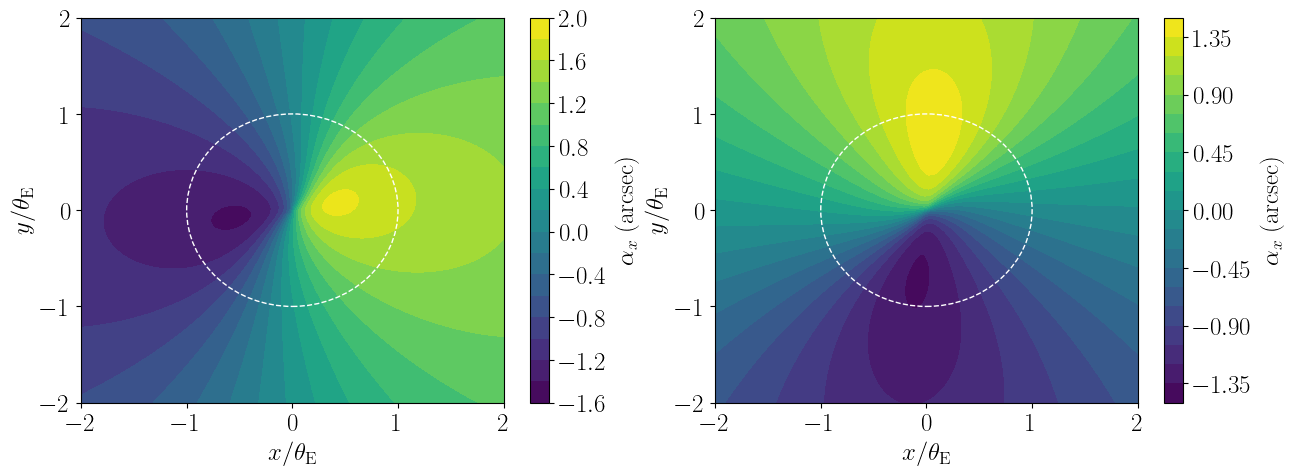

In [21]:
# plot alpha_x and alpha_x
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, alpha_i in enumerate([alpha_x, alpha_y]):
    
    ax = axes[i]
    contours = ax.contourf(X, Y, alpha_i, levels=20)
    ax.set_xlabel(r"$x/\theta_{\rm E}$")
    ax.set_ylabel(r"$y/\theta_{\rm E}$")
    fig.colorbar(contours, ax=ax, label=r'$\alpha_x$ (arcsec)')
    ax.add_artist(Circle(xy=(0, 0), radius=1, facecolor="none", edgecolor='white', ls='--'))

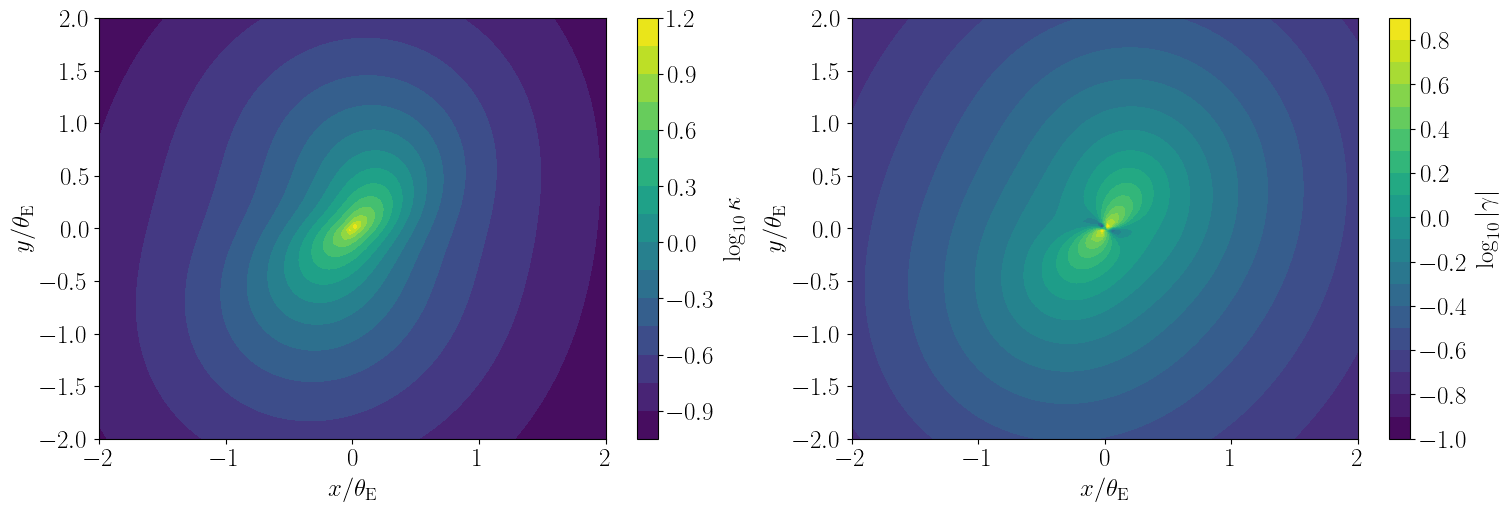

In [22]:
kappa = (H_xx + H_yy) / 2
gamma1 = H_xx - kappa
gamma2 = H_xy
gamma = (gamma1**2 + gamma2**2)**0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

ax = axes[0]
contours = ax.contourf(X, Y, np.log10(kappa), levels=20)
ax.set_xlabel(r"$x/\theta_{\rm E}$")
ax.set_ylabel(r"$y/\theta_{\rm E}$")
fig.colorbar(contours, ax=ax, label=r'$\log_{10}\kappa$')

ax = axes[1]
contours = ax.contourf(X, Y, np.log10(gamma), levels=20)
ax.set_xlabel(r"$x/\theta_{\rm E}$")
ax.set_ylabel(r"$y/\theta_{\rm E}$")
fig.colorbar(contours, ax=ax, label=r'$\log_{10}|\gamma|$')

plt.show();

## Test the consistency of derivatives 

In [23]:
x = np.linspace(-1, 1, 100) * params_radial['theta_E']
y = np.linspace(-1, 1, 100) * params_radial['theta_E']
X, Y = np.meshgrid(x, y)

psi, (alpha_x, alpha_y), (H_xx, H_xy, H_yy) = lensing_fields(X , Y)


# numerical calculation of the displacement angle

func = lambda x, y: lensing_fields(x, y)[0]
res = derivative(func, X, args=(Y,))
alpha_x_num = res.df

func = lambda y, x: lensing_fields(x, y)[0]
res = derivative(func, Y, args=(X,))
alpha_y_num = res.df

# numerical calculation of the Hessian

func = lambda x, y: lensing_fields(x, y)[1][0]
res = derivative(func, X, args=(Y,))
H_xx_num = res.df

func = lambda y, x: lensing_fields(x, y)[1][0]
res = derivative(func, Y, args=(X,))
H_xy_num = res.df

func = lambda y, x: lensing_fields(x, y)[1][1]
res = derivative(func, Y, args=(X,))
H_yy_num = res.df

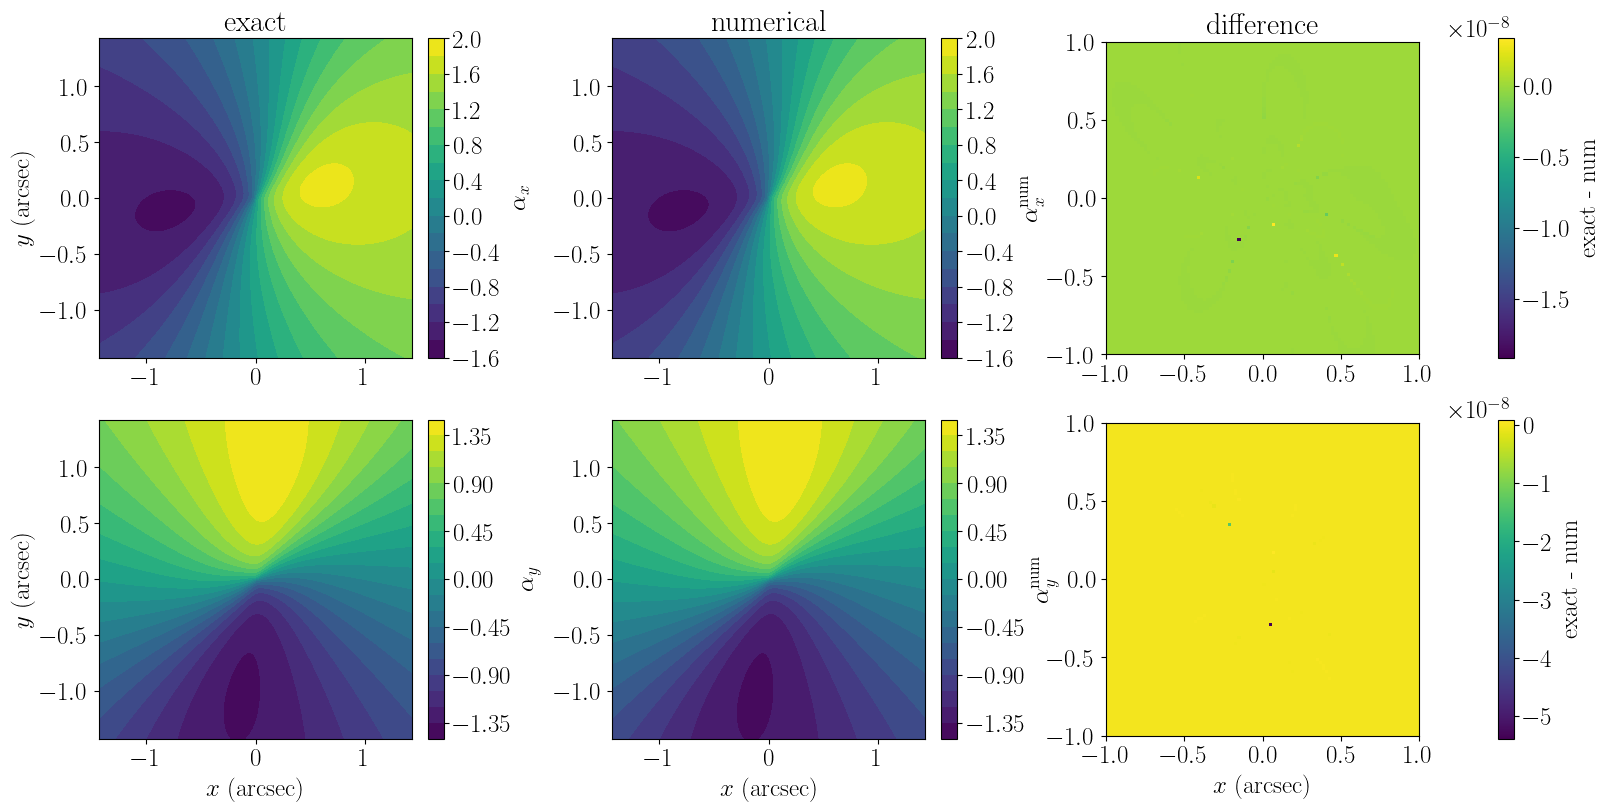

In [24]:
# consistency of the first derivatives

fig, axes = plt.subplots(2, 3, figsize=(16, 4*2), layout="constrained")

alpha_num = [alpha_x_num, alpha_y_num]
labels = [[r'$\alpha_x$', r'$\alpha_x^{\rm num}$', r'exact - num'],
          [r'$\alpha_y$', r'$\alpha_y^{\rm num}$', r'exact - num']]

for i, alpha_i in enumerate([alpha_x, alpha_y]):

    alpha_i_num = alpha_num[i]
    diff = alpha_i - alpha_i_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, alpha_i, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, alpha_i_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(2):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[1, j].set_xlabel(r"$x$ (arcsec)")

axes[0, 0].set_title(r"exact")
axes[0, 1].set_title(r"numerical")
axes[0, 2].set_title(r"difference")

plt.show();

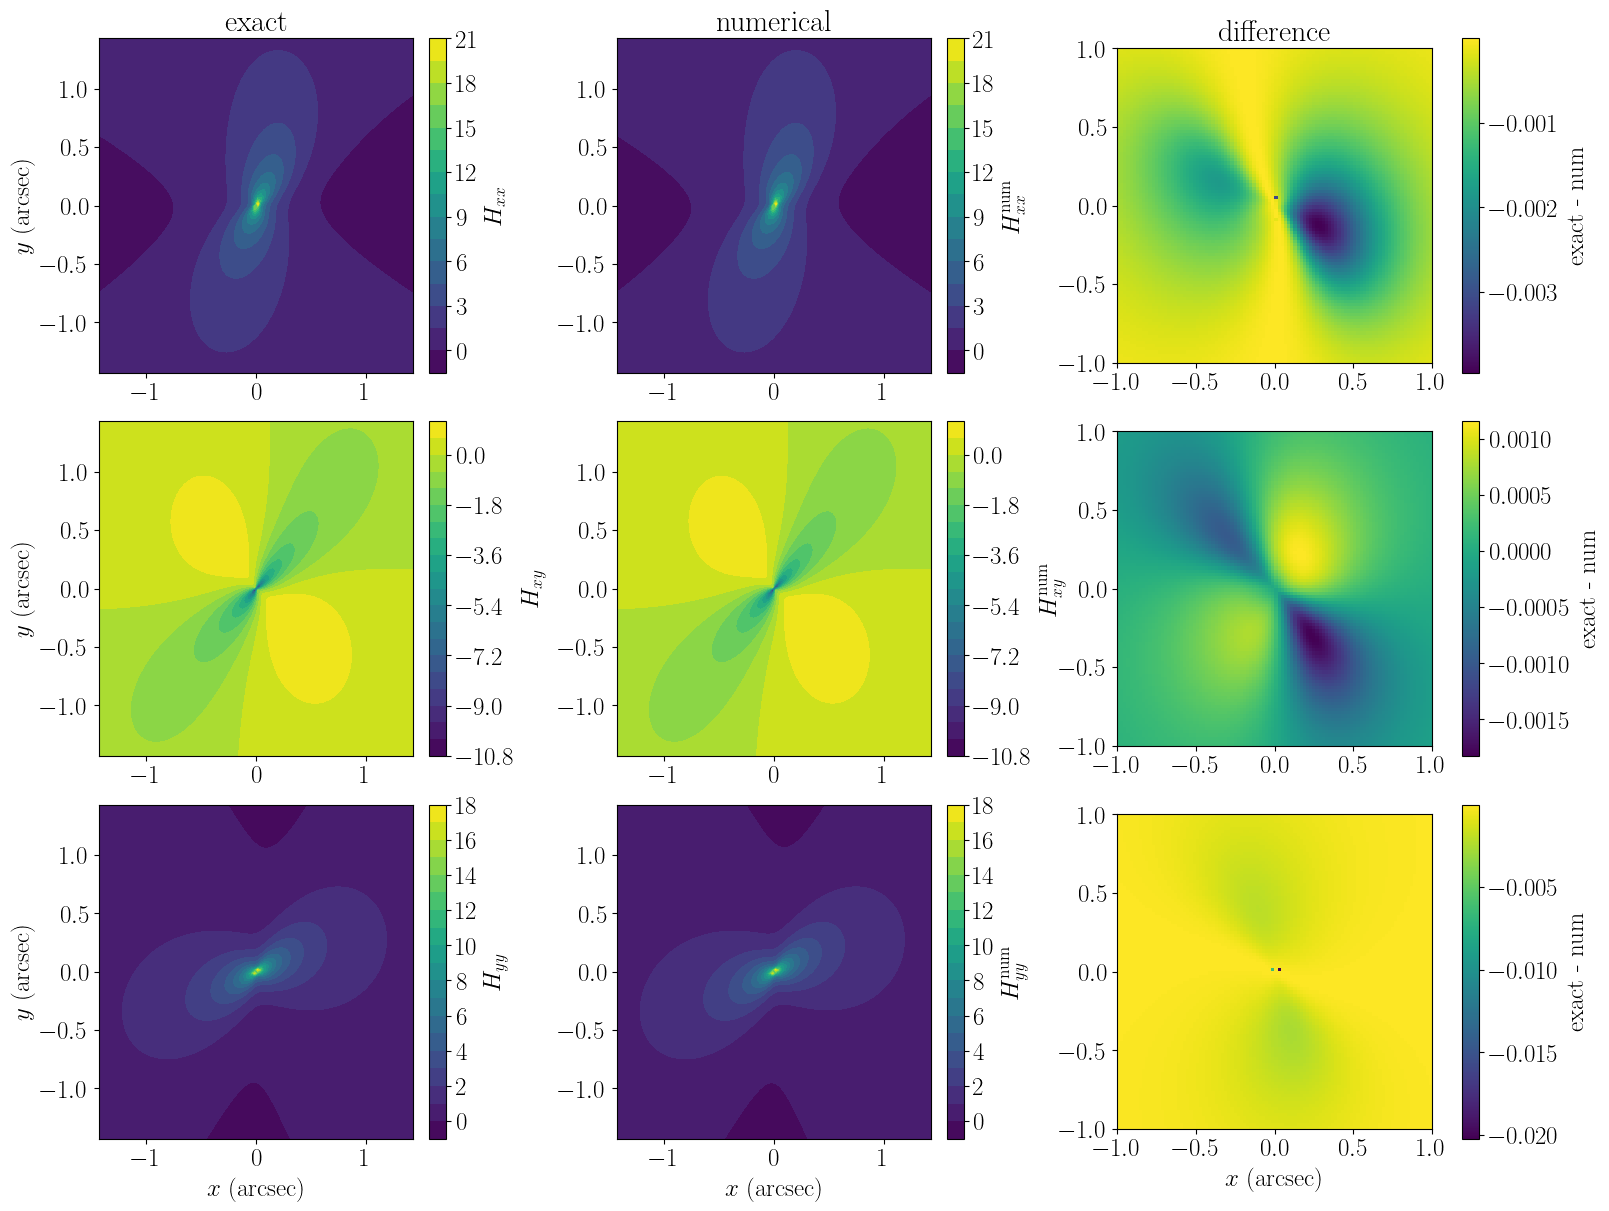

In [25]:
# consistency of the second derivatives

fig, axes = plt.subplots(3, 3, figsize=(16, 4*3), layout="constrained")

H_num = [H_xx_num, H_xy_num, H_yy_num]
labels = [[r'$H_{xx}$', r'$H_{xx}^{\rm num}$', r'exact - num'],
          [r'$H_{xy}$', r'$H_{xy}^{\rm num}$', r'exact - num'],
          [r'$H_{yy}$', r'$H_{yy}^{\rm num}$', r'exact - num']]

for i, H_ij in enumerate([H_xx, H_xy, H_yy]):

    H_ij_num = H_num[i]
    diff = H_ij - H_ij_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, H_ij, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, H_ij_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(3):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[2, j].set_xlabel(r"$x$ (arcsec)")

axes[0, 0].set_title(r"exact")
axes[0, 1].set_title(r"numerical")
axes[0, 2].set_title(r"difference")

plt.show();

## Performance

If we need to evaluate the displacement angle, we can stop at first order. How many iterations do we need for a good precision?

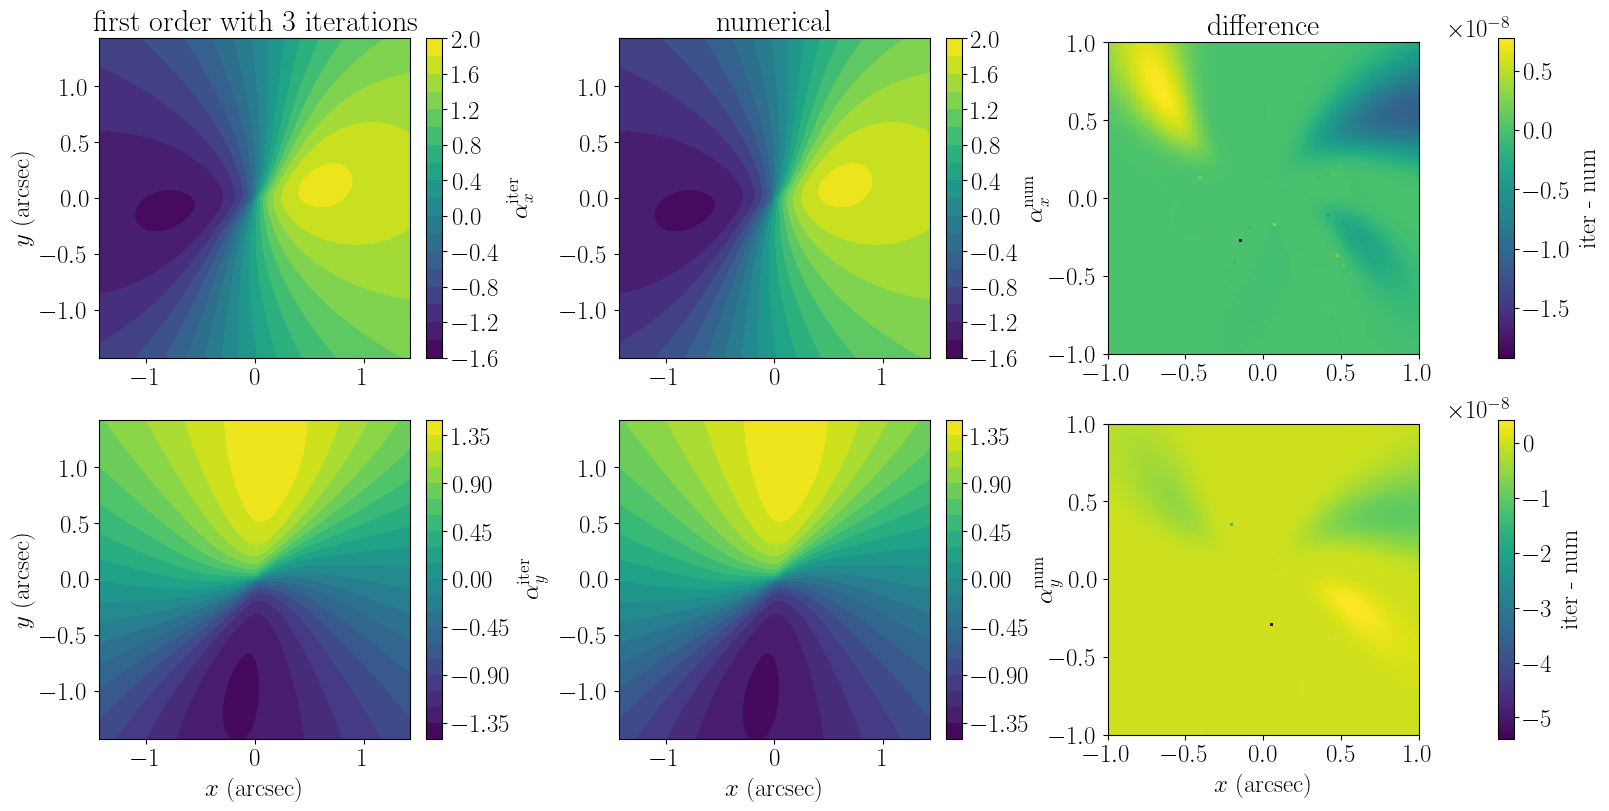

In [26]:
x = np.linspace(-1, 1, 100) * params_radial['theta_E']
y = np.linspace(-1, 1, 100) * params_radial['theta_E']
X, Y = np.meshgrid(x, y)

# iterative calculation stopping at first order

N_iter = 3
_, (alpha_x, alpha_y), _ = lensing_fields(X, Y, N_iter, second_derivatives=False)


# numerical calculation of the displacement angle

func = lambda x, y: lensing_fields(x, y, N_iter=10, second_derivatives=True)[0]
res = derivative(func, X, args=(Y,))
alpha_x_num = res.df

func = lambda y, x: lensing_fields(x, y, N_iter=10, second_derivatives=True)[0]
res = derivative(func, Y, args=(X,))
alpha_y_num = res.df

# plot of the difference

fig, axes = plt.subplots(2, 3, figsize=(16, 4*2), layout="constrained")

alpha_num = [alpha_x_num, alpha_y_num]
labels = [[r'$\alpha_x^{\rm iter}$', r'$\alpha_x^{\rm num}$', r'iter - num'],
          [r'$\alpha_y^{\rm iter}$', r'$\alpha_y^{\rm num}$', r'iter - num']]

for i, alpha_i in enumerate([alpha_x, alpha_y]):

    alpha_i_num = alpha_num[i]
    diff = alpha_i - alpha_i_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, alpha_i, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, alpha_i_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(2):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[1, j].set_xlabel(r"$x$ (arcsec)")

axes[0, 0].set_title(r"first order with {} iterations".format(N_iter))
axes[0, 1].set_title(r"numerical")
axes[0, 2].set_title(r"difference")

plt.show();

### Timing

In [27]:
for parameters in [(3, True), (3, False), (5, False)]:

    N_sample = 100 # number of executions to average over
    dt = 0
    
    for i in range(N_sample):
    
        start = time.perf_counter()
        N_iter, second_derivatives = parameters
        lensing_fields(X, Y, N_iter, second_derivatives)
        end = time.perf_counter()

        dt += end - start

    t1 = dt / N_sample * 1000 # average time in ms
    print("Average timing for {} iterations and second_derivatives={} = {} ms".format(N_iter, second_derivatives, t1))

Average timing for 3 iterations and second_derivatives=True = 11.772959353402257 ms
Average timing for 3 iterations and second_derivatives=False = 6.528981705196202 ms
Average timing for 5 iterations and second_derivatives=False = 8.844915106892586 ms


# Lenstronomy implementation

In [28]:
from lenstronomy.LensModel.lens_model import LensModel

lens_model_list = ['EPL']
lens_model = LensModel(lens_model_list)

TO DO: implementation in lenstronomy. My current conclusion is that the implementation should be made at the level of the SinglePlane class. The profiles should be 'ELLIPTICAL_RADIUS_XXX' for the elliptical profile and 'RADIAL_PROFILE_XXX' for the radial profile. The former will contain the ellipse fields and the latter will contain the radial profile to be used.

In the init, the class should regognise if both ingredients are present and treat them separately. This will be a modification similar to SinglePlaneLOS, but I need to put it at the level of SinglePlane, otherwise it cannot work with the LOS.